<a href="https://colab.research.google.com/github/haarish009/rice-disease-models/blob/main/Copy_of_Untitled7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===== INSTALL & IMPORTS =====
!pip install -q kagglehub efficientnet

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, applications
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import os
from glob import glob
import kagglehub
import gc
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Force memory cleanup
keras.backend.clear_session()
gc.collect()

In [ ]:
# ===== DOWNLOAD DATASET =====
path = kagglehub.dataset_download("loki4514/rice-leaf-diseases-detection")
TRAIN_PATH = os.path.join(path, "Rice_Leaf_Diease/Rice_Leaf_Diease/train")
print("Training folder:", TRAIN_PATH)

# ===== CONFIG =====
IMG_SIZE = (160, 160)  # REDUCED from 224 to save memory
BATCH_SIZE = 16  # REDUCED from 32
EPOCHS_STAGE1 = 20  # REDUCED for faster iteration
EPOCHS_STAGE2 = 30
LR_STAGE1 = 1e-3
LR_STAGE2 = 1e-4
ATTENTION_THRESHOLD = 0.5

 13%|█▎        | 1.07G/8.03G [00:30<03:15, 38.2MB/s]


KeyboardInterrupt: 

In [ ]:
# ===== GET FILE PATHS (DON'T LOAD IMAGES YET) =====
def get_file_paths(base_path):
    file_paths = []
    labels = []
    class_names = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])

    print(f"\nFound {len(class_names)} classes:")
    for idx, class_name in enumerate(class_names):
        print(f"  {idx}: {class_name}")
        class_path = os.path.join(base_path, class_name)
        img_files = glob(os.path.join(class_path, '*.[jJ][pP][gG]')) + \
                    glob(os.path.join(class_path, '*.[pP][nN][gG]'))

        print(f"    Found {len(img_files)} images")
        file_paths.extend(img_files)
        labels.extend([idx] * len(img_files))

    return file_paths, np.array(labels), class_names

file_paths, labels, CLASS_NAMES = get_file_paths(TRAIN_PATH)
NUM_CLASSES = len(CLASS_NAMES)

print(f"\nTotal images: {len(file_paths)}")
print(f"Number of classes: {NUM_CLASSES}")



Found 10 classes:
  0: bacterial_leaf_blight
    Found 1386 images
  1: brown_spot
    Found 1480 images
  2: healthy
    Found 1491 images
  3: leaf_blast
    Found 1801 images
  4: leaf_scald
    Found 1670 images
  5: narrow_brown_spot
    Found 1416 images
  6: neck_blast
    Found 1000 images
  7: rice_hispa
    Found 1461 images
  8: sheath_blight
    Found 1578 images
  9: tungro
    Found 1740 images

Total images: 15023
Number of classes: 10


In [ ]:
## ===== SPLIT FILE PATHS (NOT IMAGES) =====
train_paths, temp_paths, y_train, y_temp = train_test_split(
    file_paths, labels, test_size=0.3, stratify=labels, random_state=42
)
val_paths, test_paths, y_val, y_test = train_test_split(
    temp_paths, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"Train: {len(train_paths)}, Val: {len(val_paths)}, Test: {len(test_paths)}")


Train: 10516, Val: 2253, Test: 2254


In [ ]:
# ===== MEMORY-EFFICIENT DATA GENERATOR =====
class MemoryEfficientGenerator(keras.utils.Sequence):
    def __init__(self, file_paths, labels, batch_size=16, img_size=(160, 160), augment=False, shuffle=True):
        self.file_paths = file_paths
        self.labels = labels
        self.batch_size = batch_size
        self.img_size = img_size
        self.augment = augment
        self.shuffle = shuffle
        self.indices = np.arange(len(file_paths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.file_paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]

        batch_images = []
        batch_labels = []

        for i in batch_indices:
            img = cv2.imread(self.file_paths[i])
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, self.img_size)
                img = img.astype('float32') / 255.0

                if self.augment and np.random.random() > 0.5:
                    if np.random.random() > 0.5:
                        img = np.fliplr(img)
                    if np.random.random() > 0.5:
                        img = np.flipud(img)

                batch_images.append(img)
                batch_labels.append(self.labels[i])

        return np.array(batch_images), keras.utils.to_categorical(batch_labels, NUM_CLASSES)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

# Create generators
train_gen = MemoryEfficientGenerator(train_paths, y_train, BATCH_SIZE, IMG_SIZE, augment=True)
val_gen = MemoryEfficientGenerator(val_paths, y_val, BATCH_SIZE, IMG_SIZE, augment=False, shuffle=False)
test_gen = MemoryEfficientGenerator(test_paths, y_test, BATCH_SIZE, IMG_SIZE, augment=False, shuffle=False)


In [ ]:
# ===== STAGE 1: LIGHTWEIGHT CNN =====
def build_stage1_cnn():
    base_model = applications.MobileNetV2(  # Lighter than EfficientNet
        include_top=False,
        weights='imagenet',
        input_shape=(*IMG_SIZE, 3),
        alpha=0.75  # Width multiplier to reduce size
    )

    base_model.trainable = False  # Freeze initially

    inputs = layers.Input(shape=(*IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)  # Smaller
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    return models.Model(inputs, outputs)

print("\n" + "="*80)
print("BUILDING STAGE 1: LIGHTWEIGHT CNN")
print("="*80)

stage1_model = build_stage1_cnn()
stage1_model.compile(
    optimizer=keras.optimizers.Adam(LR_STAGE1),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



BUILDING STAGE 1: LIGHTWEIGHT CNN
5903360/5903360 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
#-------------checkpoint one-------------------#

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Create folder for saved models
import os
os.makedirs("/content/models", exist_ok=True)

# Stage 1 model (segmentation)
checkpoint_s1 = ModelCheckpoint(
    '/content/drive/MyDrive/models/rice_stage1_best.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)


In [ ]:
# ===== TRAIN STAGE 1 =====
print("\n" + "="*80)
print("TRAINING STAGE 1")
print("="*80)

history_s1 = stage1_model.fit(
    train_gen,
    epochs=EPOCHS_STAGE1,
    validation_data=val_gen,
    callbacks=[checkpoint_s1, early_stop, reduce_lr]
)

# Save the final trained model (optional)
stage1_model.save("/content/models/stage1_final_model.keras")

# Clear memory
import gc
gc.collect()


TRAINING STAGE 1


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
658/658 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.6031 - loss: 1.1657
Epoch 1: val_accuracy improved from -inf to 0.83134, saving model to /content/drive/MyDrive/models/rice_stage1_best.h5


658/658 ━━━━━━━━━━━━━━━━━━━━ 379s 532ms/step - accuracy: 0.6033 - loss: 1.1652 - val_accuracy: 0.8313 - val_loss: 0.4809 - learning_rate: 0.0010
Epoch 2/20
658/658 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.8072 - loss: 0.5475
Epoch 2: val_accuracy improved from 0.83134 to 0.87040, saving model to /content/drive/MyDrive/models/rice_stage1_best.h5


658/658 ━━━━━━━━━━━━━━━━━━━━ 200s 304ms/step - accuracy: 0.8072 - loss: 0.5474 - val_accuracy: 0.8704 - val_loss: 0.3782 - learning_rate: 0.0010
Epoch 3/20
658/658 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.8474 - loss: 0.4229
Epoch 3: val_accuracy improved from 0.87040 to 0.88327, saving model to /content/drive/MyDrive/models/rice_stage1_best.h5


...

658/658 ━━━━━━━━━━━━━━━━━━━━ 195s 296ms/step - accuracy: 0.9106 - loss: 0.2403 - val_accuracy: 0.9396 - val_loss: 0.1847 - learning_rate: 0.0010
Epoch 13/20
658/658 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.9144 - loss: 0.2361
Epoch 13: val_accuracy did not improve from 0.93964
658/658 ━━━━━━━━━━━━━━━━━━━━ 199s 303ms/step - accuracy: 0.9144 - loss: 0.2361 - val_accuracy: 0.9379 - val_loss: 0.1794 - learning_rate: 0.0010
Epoch 14/20
658/658 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.9220 - loss: 0.2205
Epoch 14: val_accuracy did not improve from 0.93964
658/658 ━━━━━━━━━━━━━━━━━━━━ 199s 303ms/step - accuracy: 0.9220 - loss: 0.2205 - val_accuracy: 0.9303 - val_loss: 0.2097 - learning_rate: 0.0010
Epoch 15/20
658/658 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.9268 - loss: 0.2071
Epoch 15: val_accuracy did not improve from 0.93964
658/658 ━━━━━━━━━━━━━━━━━━━━ 197s 300ms/step - accuracy: 0.9268 - loss: 0.2071 - val_accuracy: 0.9299 - val_loss: 0.1924 - learning_rate: 0.00

658/658 ━━━━━━━━━━━━━━━━━━━━ 209s 318ms/step - accuracy: 0.9351 - loss: 0.1758 - val_accuracy: 0.9450 - val_loss: 0.1662 - learning_rate: 5.0000e-04
Epoch 18/20
658/658 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.9380 - loss: 0.1589
Epoch 18: val_accuracy did not improve from 0.94496
658/658 ━━━━━━━━━━━━━━━━━━━━ 205s 311ms/step - accuracy: 0.9380 - loss: 0.1589 - val_accuracy: 0.9432 - val_loss: 0.1621 - learning_rate: 5.0000e-04
Epoch 19/20
658/658 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.9419 - loss: 0.1619
Epoch 19: val_accuracy improved from 0.94496 to 0.94896, saving model to /content/drive/MyDrive/models/rice_stage1_best.h5


658/658 ━━━━━━━━━━━━━━━━━━━━ 202s 307ms/step - accuracy: 0.9419 - loss: 0.1619 - val_accuracy: 0.9490 - val_loss: 0.1668 - learning_rate: 5.0000e-04
Epoch 20/20
658/658 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.9412 - loss: 0.1600
Epoch 20: val_accuracy improved from 0.94896 to 0.95118, saving model to /content/drive/MyDrive/models/rice_stage1_best.h5


658/658 ━━━━━━━━━━━━━━━━━━━━ 198s 301ms/step - accuracy: 0.9412 - loss: 0.1600 - val_accuracy: 0.9512 - val_loss: 0.1499 - learning_rate: 5.0000e-04


1471

In [ ]:
# ===== EVALUATE STAGE 1 =====
print("\nEvaluating Stage 1...")
stage1_results = stage1_model.evaluate(test_gen)
print(f"Stage 1 Test Accuracy: {stage1_results[1]:.4f}")



Evaluating Stage 1...


NameError: name 'stage1_model' is not defined

In [ ]:
base_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_0.75_160            │ (None, 5, 5, 1280)     │     1,382,064 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,547,322 (5.90 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 1,382,064 (5.27 MB)

In [ ]:
from tensorflow import keras

# Load Stage 1 model
stage1_model = keras.models.load_model(
    '/content/drive/MyDrive/models/rice_stage1_best.h5'
)

In [ ]:
for i, layer in enumerate(stage1_model.layers):
    print(i, layer.name, layer.output_shape if hasattr(layer, "output_shape") else"")

0 input_layer_1 
1 mobilenetv2_0.75_160 (None, 5, 5, 1280)
2 global_average_pooling2d 
3 dropout 
4 dense 
5 dropout_1 
6 dense_1 


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

print("Generating predictions for Stage 1 model...")
y_pred_s1_raw = stage1_model.predict(test_gen)
y_pred_s1 = np.argmax(y_pred_s1_raw, axis=1)

# Get true labels from the test generator
y_true_s1 = []
for _, labels in test_gen:
    y_true_s1.extend(np.argmax(labels, axis=1))
y_true_s1 = np.array(y_true_s1)

print("Calculating Confusion Matrix for Stage 1 model...")
cm_s1 = confusion_matrix(y_true_s1, y_pred_s1)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_s1, annot=True, fmt="d",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Stage 1 Model Confusion Matrix (MobileNetV2)")
plt.show()

print("\nClassification Report for Stage 1 Model:")
print(classification_report(y_true_s1, y_pred_s1, target_names=CLASS_NAMES))

Generating predictions for Stage 1 model...


NameError: name 'test_gen' is not defined


BUILDING GRAD-CAM++ FOR ATTENTION MECHANISM
Copying weights from trained Stage 1 model...
✅ Grad model created successfully
   Conv output shape: (None, 5, 5, 1280)
   Prediction output shape: (None, 10)
✅ Test forward pass successful!
   Conv shape: (1, 5, 5, 1280), Pred shape: (1, 10)

Testing Grad-CAM++ on sample images...
✅ Predictions match: True
Predicted class: 3 (leaf_blast)
True class: 3 (leaf_blast)
Prediction confidence: 0.7138
✅ Mask generated successfully!
   Mask shape: (160, 160)
   Mask range: [0.000, 1.000]
   Active pixels: 10839 (42.3%)


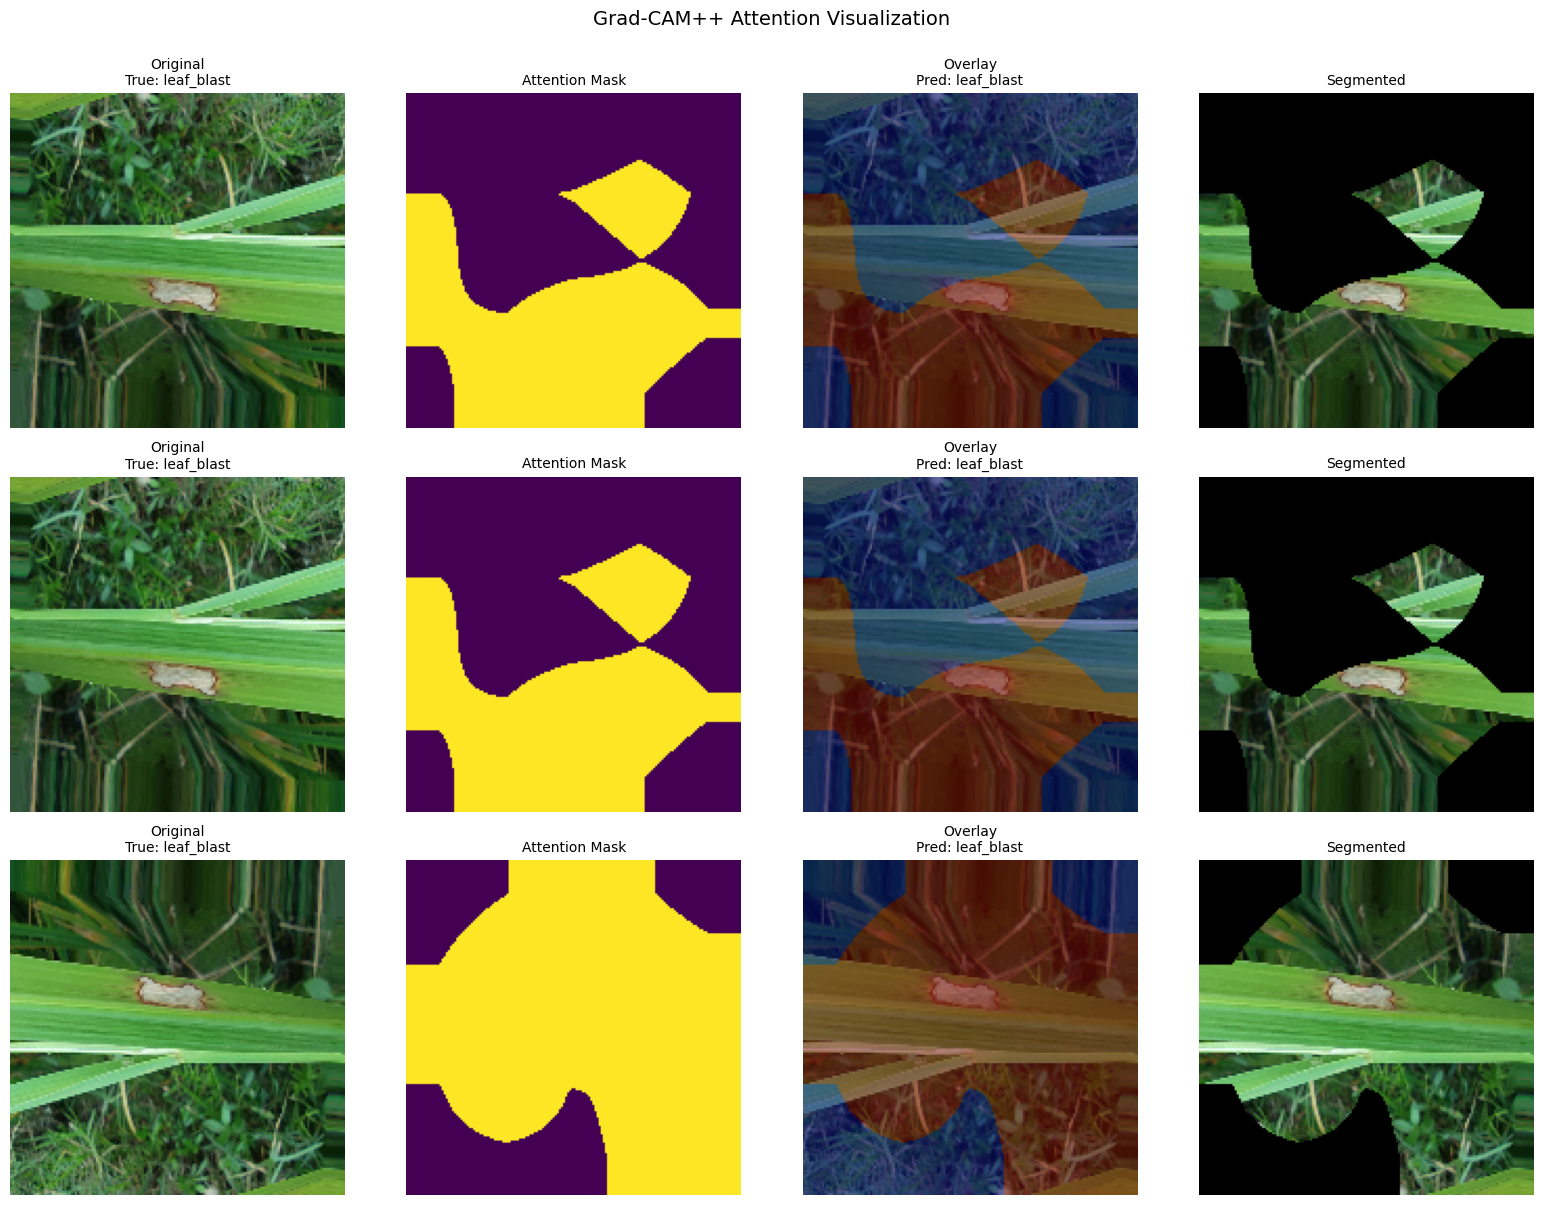


✅ Grad-CAM++ test successful! Proceeding with segmented generators...

CREATING SEGMENTED GENERATORS FOR STAGE 2
✅ Segmented generators created successfully


In [ ]:
# ===== COMPLETE FIX: REBUILD GRAD MODEL FROM SCRATCH =====
print("\n" + "="*80)
print("BUILDING GRAD-CAM++ FOR ATTENTION MECHANISM")
print("="*80)

# Load the weights from stage1_model but rebuild the architecture
mobilenet_base = applications.MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(*IMG_SIZE, 3),
    alpha=0.75
)

# Build new model with explicit layer access
inputs = layers.Input(shape=(*IMG_SIZE, 3))
x = mobilenet_base(inputs, training=False)

# Store the conv output for Grad-CAM
conv_output = x  # This is the output we want for Grad-CAM

# Continue with classification layers
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

# Create the full model
grad_model_full = models.Model(inputs, outputs)

# Copy weights from trained stage1_model
print("Copying weights from trained Stage 1 model...")
grad_model_full.set_weights(stage1_model.get_weights())

# Now create the grad model with both conv and final outputs
grad_model = tf.keras.models.Model(
    inputs=grad_model_full.input,
    outputs=[conv_output, grad_model_full.output]
)

print(f"✅ Grad model created successfully")
print(f"   Conv output shape: {conv_output.shape}")
print(f"   Prediction output shape: {outputs.shape}")

# Verify it works
test_input = np.random.random((1, 160, 160, 3)).astype('float32')
test_conv, test_pred = grad_model(test_input)
print(f"✅ Test forward pass successful!")
print(f"   Conv shape: {test_conv.shape}, Pred shape: {test_pred.shape}")

class GradCAMPlusPlus:
    def __init__(self, model):
        self.model = model

    def generate_mask(self, image, class_idx, threshold=0.5):
        """Generate Grad-CAM++ attention mask"""
        # Ensure image is float32 and normalized
        if image.max() > 1.0:
            image = image.astype('float32') / 255.0

        # Convert to tensor
        img_array = np.expand_dims(image, axis=0)
        img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

        # Use GradientTape to compute gradients
        with tf.GradientTape() as tape:
            tape.watch(img_tensor)
            # Forward pass
            conv_outputs, predictions = self.model(img_tensor)
            # Get the score for the predicted class
            class_channel = predictions[:, class_idx]

        # Compute gradients of the class output with respect to the feature maps
        grads = tape.gradient(class_channel, conv_outputs)

        if grads is None:
            print("⚠️ Warning: No gradients computed, returning uniform mask")
            return np.ones((image.shape[0], image.shape[1]))

        # Grad-CAM++ computation
        # Compute alpha (pixel-wise weights)
        conv_outputs_np = conv_outputs[0].numpy()
        grads_np = grads[0].numpy()

        # Calculate alpha weights
        numerator = grads_np
        denominator = 2.0 * grads_np + np.sum(conv_outputs_np * grads_np, axis=(0, 1), keepdims=True)
        alpha = numerator / (denominator + 1e-7)

        # Calculate channel-wise weights
        weights = np.sum(alpha * np.maximum(grads_np, 0), axis=(0, 1))

        # Generate heatmap
        heatmap = np.sum(weights * conv_outputs_np, axis=-1)
        heatmap = np.maximum(heatmap, 0)  # ReLU

        # Normalize
        if heatmap.max() > 0:
            heatmap = heatmap / heatmap.max()
        else:
            print("⚠️ Warning: Zero heatmap, returning uniform mask")
            return np.ones((image.shape[0], image.shape[1]))

        # Resize to original image size
        heatmap_resized = cv2.resize(heatmap, (image.shape[1], image.shape[0]))

        # Apply threshold
        mask = (heatmap_resized > threshold).astype('float32')

        # Ensure mask has some content
        if mask.sum() < 10:
            threshold_val = np.percentile(heatmap_resized, 70)
            mask = (heatmap_resized > threshold_val).astype('float32')

        return mask

# Initialize Grad-CAM++
grad_cam = GradCAMPlusPlus(grad_model)

# Test visualization
print("\nTesting Grad-CAM++ on sample images...")
sample_img, sample_label = next(iter(train_gen))

# Verify predictions match
pred_original = stage1_model.predict(sample_img[0:1], verbose=0)
pred_grad = grad_model_full.predict(sample_img[0:1], verbose=0)
print(f"✅ Predictions match: {np.allclose(pred_original, pred_grad)}")

pred_idx = np.argmax(pred_original[0])
true_idx = np.argmax(sample_label[0])

print(f"Predicted class: {pred_idx} ({CLASS_NAMES[pred_idx]})")
print(f"True class: {true_idx} ({CLASS_NAMES[true_idx]})")
print(f"Prediction confidence: {pred_original[0][pred_idx]:.4f}")

try:
    mask = grad_cam.generate_mask(sample_img[0], pred_idx)

    print(f"✅ Mask generated successfully!")
    print(f"   Mask shape: {mask.shape}")
    print(f"   Mask range: [{mask.min():.3f}, {mask.max():.3f}]")
    print(f"   Active pixels: {mask.sum():.0f} ({mask.sum()/mask.size*100:.1f}%)")

    # Visualize multiple samples
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))

    for idx in range(3):
        if idx > 0:
            sample_img, sample_label = next(iter(train_gen))
            pred = stage1_model.predict(sample_img[0:1], verbose=0)
            pred_idx = np.argmax(pred[0])
            true_idx = np.argmax(sample_label[0])
            mask = grad_cam.generate_mask(sample_img[0], pred_idx)

        # Original
        axes[idx, 0].imshow(sample_img[0])
        axes[idx, 0].set_title(f"Original\nTrue: {CLASS_NAMES[true_idx]}", fontsize=10)
        axes[idx, 0].axis('off')

        # Mask
        im = axes[idx, 1].imshow(mask, cmap='viridis')
        axes[idx, 1].set_title("Attention Mask", fontsize=10)
        axes[idx, 1].axis('off')

        # Overlay
        axes[idx, 2].imshow(sample_img[0])
        axes[idx, 2].imshow(mask, cmap='jet', alpha=0.5)
        axes[idx, 2].set_title(f"Overlay\nPred: {CLASS_NAMES[pred_idx]}", fontsize=10)
        axes[idx, 2].axis('off')

        # Segmented
        segmented = sample_img[0] * mask[:, :, np.newaxis]
        axes[idx, 3].imshow(segmented)
        axes[idx, 3].set_title("Segmented", fontsize=10)
        axes[idx, 3].axis('off')

    plt.suptitle("Grad-CAM++ Attention Visualization", fontsize=14, y=1.00)
    plt.tight_layout()
    plt.show()

    print("\n✅ Grad-CAM++ test successful! Proceeding with segmented generators...")

except Exception as e:
    print(f"\n❌ Error during Grad-CAM++: {str(e)}")
    import traceback
    traceback.print_exc()

    print("\n⚠️  FALLBACK: Proceeding WITHOUT Grad-CAM++ segmentation")
    print("    Stage 2 will train on original images instead")

    # Set grad_cam to None to trigger fallback in generator
    grad_cam = None

print("\n" + "="*80)

# ===== CREATE SEGMENTED GENERATORS (with fallback) =====
if grad_cam is not None:
    print("CREATING SEGMENTED GENERATORS FOR STAGE 2")
    print("="*80)

    class SegmentedGenerator(keras.utils.Sequence):
        def __init__(self, file_paths, labels, stage1_model, grad_cam, batch_size=16, img_size=(160, 160)):
            self.file_paths = file_paths
            self.labels = labels
            self.stage1_model = stage1_model
            self.grad_cam = grad_cam
            self.batch_size = batch_size
            self.img_size = img_size

        def __len__(self):
            return int(np.ceil(len(self.file_paths) / self.batch_size))

        def __getitem__(self, idx):
            batch_indices = range(idx * self.batch_size, min((idx + 1) * self.batch_size, len(self.file_paths)))

            batch_images = []
            batch_labels = []

            for i in batch_indices:
                img = cv2.imread(self.file_paths[i])
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = cv2.resize(img, self.img_size).astype('float32') / 255.0

                    # Get prediction for this image
                    pred = self.stage1_model.predict(img[np.newaxis, ...], verbose=0)
                    pred_class = np.argmax(pred[0])

                    # Generate attention mask
                    mask = self.grad_cam.generate_mask(img, pred_class, threshold=ATTENTION_THRESHOLD)

                    # Apply mask (3 channels)
                    mask_3ch = np.repeat(mask[:, :, np.newaxis], 3, axis=2)
                    segmented = img * mask_3ch

                    batch_images.append(segmented)
                    batch_labels.append(self.labels[i])

            return np.array(batch_images), keras.utils.to_categorical(batch_labels, NUM_CLASSES)

    train_seg_gen = SegmentedGenerator(train_paths, y_train, stage1_model, grad_cam, BATCH_SIZE, IMG_SIZE)
    val_seg_gen = SegmentedGenerator(val_paths, y_val, stage1_model, grad_cam, BATCH_SIZE, IMG_SIZE)
    test_seg_gen = SegmentedGenerator(test_paths, y_test, stage1_model, grad_cam, BATCH_SIZE, IMG_SIZE)

    print("✅ Segmented generators created successfully")
else:
    print("USING ORIGINAL IMAGES (Grad-CAM++ not available)")
    print("="*80)
    train_seg_gen = train_gen
    val_seg_gen = val_gen
    test_seg_gen = test_gen
    print("✅ Using original image generators")

In [ ]:
# Debug: Check model structure
print("Stage 1 model layers:")
for i, layer in enumerate(stage1_model.layers):
    print(f"{i}: {layer.name} - {layer.__class__.__name__}")
    if hasattr(layer, 'output_shape'):
        print(f"   Output shape: {layer.output_shape}")

print("\n" + "="*50)
print("MobileNetV2 internal layers:")
mobilenet = stage1_model.get_layer('mobilenetv2_0.75_160')
for i, layer in enumerate(mobilenet.layers[-5:]):  # Last 5 layers
    print(f"{i}: {layer.name} - {layer.__class__.__name__}")

Stage 1 model layers:
0: input_layer_1 - InputLayer
1: mobilenetv2_0.75_160 - Functional
   Output shape: (None, 5, 5, 1280)
2: global_average_pooling2d - GlobalAveragePooling2D
3: dropout - Dropout
4: dense - Dense
5: dropout_1 - Dropout
6: dense_1 - Dense

MobileNetV2 internal layers:
0: block_16_project - Conv2D
1: block_16_project_BN - BatchNormalization
2: Conv_1 - Conv2D
3: Conv_1_bn - BatchNormalization
4: out_relu - ReLU


In [ ]:
# ===== STEP 1: BUILD GRAD-CAM MODEL (from your document 1) =====
print("\n" + "="*80)
print("BUILDING GRAD-CAM++ FOR ATTENTION MECHANISM")
print("="*80)

mobilenet_base = applications.MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(*IMG_SIZE, 3),
    alpha=0.75
)

inputs = layers.Input(shape=(*IMG_SIZE, 3))
x = mobilenet_base(inputs, training=False)
conv_output = x
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

grad_model_full = models.Model(inputs, outputs)
grad_model_full.set_weights(stage1_model.get_weights())

grad_model = tf.keras.models.Model(
    inputs=grad_model_full.input,
    outputs=[conv_output, grad_model_full.output]
)

print(f"✅ Grad model created successfully")


class GradCAMPlusPlus:
    def __init__(self, model):
        self.model = model

    def generate_mask(self, image, class_idx, threshold=0.5):
        try:
            if image.max() > 1.0:
                image = image.astype('float32') / 255.0

            img_array = np.expand_dims(image, axis=0)
            img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

            with tf.GradientTape() as tape:
                tape.watch(img_tensor)
                conv_outputs, predictions = self.model(img_tensor)
                class_channel = predictions[:, class_idx]

            grads = tape.gradient(class_channel, conv_outputs)

            if grads is None or tf.reduce_any(tf.math.is_nan(grads)):
                return np.ones((image.shape[0], image.shape[1]), dtype='float32')

            conv_outputs_np = conv_outputs[0].numpy()
            grads_np = grads[0].numpy()

            # Check for NaN or Inf
            if np.isnan(conv_outputs_np).any() or np.isnan(grads_np).any():
                return np.ones((image.shape[0], image.shape[1]), dtype='float32')

            numerator = grads_np
            denominator = 2.0 * grads_np + np.sum(conv_outputs_np * grads_np, axis=(0, 1), keepdims=True)
            alpha = numerator / (denominator + 1e-7)

            weights = np.sum(alpha * np.maximum(grads_np, 0), axis=(0, 1))
            heatmap = np.sum(weights * conv_outputs_np, axis=-1)
            heatmap = np.maximum(heatmap, 0)

            # Check heatmap validity
            if heatmap.size == 0 or np.isnan(heatmap).any() or heatmap.max() <= 0:
                return np.ones((image.shape[0], image.shape[1]), dtype='float32')

            # Normalize
            heatmap = heatmap / heatmap.max()

            # Ensure heatmap has valid dimensions before resize
            if heatmap.shape[0] == 0 or heatmap.shape[1] == 0:
                return np.ones((image.shape[0], image.shape[1]), dtype='float32')

            # Resize with error handling
            heatmap_resized = cv2.resize(
                heatmap.astype('float32'),
                (image.shape[1], image.shape[0]),
                interpolation=cv2.INTER_LINEAR
            )

            mask = (heatmap_resized > threshold).astype('float32')

            # Ensure minimum mask coverage
            if mask.sum() < 10:
                threshold_val = np.percentile(heatmap_resized, 70)
                mask = (heatmap_resized > threshold_val).astype('float32')

            # Final safety check
            if mask.sum() == 0:
                return np.ones((image.shape[0], image.shape[1]), dtype='float32')

            return mask

        except Exception as e:
            # If anything fails, return uniform mask
            print(f"⚠️ Grad-CAM error: {str(e)[:50]}, using uniform mask")
            return np.ones((image.shape[0], image.shape[1]), dtype='float32')

grad_cam = GradCAMPlusPlus(grad_model)
print("✅ Grad-CAM++ initialized")


# ===== STEP 2: PRE-COMPUTE AND CACHE MASKS (THIS IS CRITICAL!) =====
print("\n" + "="*80)
print("PRE-COMPUTING ATTENTION MASKS - OPTIMIZED VERSION")
print("="*80)

import pickle
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')  # Suppress divide by zero warnings

def precompute_masks_optimized(file_paths, labels, stage1_model, grad_cam,
                               cache_path, img_size=(160, 160)):
    """Optimized: Process one image at a time to avoid memory issues"""

    if os.path.exists(cache_path):
        print(f"✅ Loading cached masks from {cache_path}")
        with open(cache_path, 'rb') as f:
            return pickle.load(f)

    print(f"Computing masks for {len(file_paths)} images...")
    cached_data = []
    errors = 0

    # Process one at a time for stability
    for i in tqdm(range(len(file_paths))):
        try:
            img = cv2.imread(file_paths[i])
            if img is None:
                errors += 1
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, img_size).astype('float32') / 255.0

            # Quick prediction
            pred = stage1_model.predict(img[np.newaxis, ...], verbose=0, batch_size=1)
            pred_class = np.argmax(pred[0])

            # Generate mask
            mask = grad_cam.generate_mask(img, pred_class, threshold=ATTENTION_THRESHOLD)

            # Apply mask
            mask_3ch = np.repeat(mask[:, :, np.newaxis], 3, axis=2)
            segmented = img * mask_3ch

            cached_data.append({
                'segmented': segmented.astype('float16'),
                'label': labels[i]
            })

            # Save periodically to avoid losing progress
            if (i + 1) % 1000 == 0:
                temp_path = cache_path.replace('.pkl', f'_temp_{i+1}.pkl')
                with open(temp_path, 'wb') as f:
                    pickle.dump(cached_data, f)
                print(f"\n💾 Progress saved at {i+1} images")

        except Exception as e:
            errors += 1
            # Use original image as fallback
            try:
                img = cv2.imread(file_paths[i])
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = cv2.resize(img, img_size).astype('float32') / 255.0
                    cached_data.append({
                        'segmented': img.astype('float16'),
                        'label': labels[i]
                    })
            except:
                pass

    if errors > 0:
        print(f"\n⚠️ Encountered {errors} errors (using fallback for those images)")

    # Save final result
    print(f"\nSaving {len(cached_data)} masks to {cache_path}...")
    os.makedirs(os.path.dirname(cache_path), exist_ok=True)
    with open(cache_path, 'wb') as f:
        pickle.dump(cached_data, f)

    print(f"✅ Cached {len(cached_data)} segmented images")
    return cached_data


class CachedSegmentedGenerator(keras.utils.Sequence):
    """Fast generator using pre-computed masks"""
    def __init__(self, cached_data, batch_size=16, shuffle=True):
        self.cached_data = cached_data
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(cached_data))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.cached_data) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]

        batch_images = []
        batch_labels = []

        for i in batch_indices:
            data = self.cached_data[i]
            batch_images.append(data['segmented'].astype('float32'))
            batch_labels.append(data['label'])

        return np.array(batch_images), keras.utils.to_categorical(batch_labels, NUM_CLASSES)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


# Pre-compute masks (THIS IS THE KEY TO SPEED!)
print("\n⏳ Pre-computing masks... This will take 10-20 minutes but ONLY ONCE")

train_cached = precompute_masks_optimized(
    train_paths, y_train, stage1_model, grad_cam,
    '/content/drive/MyDrive/models/train_masks_cache.pkl',
    IMG_SIZE
)

val_cached = precompute_masks_optimized(
    val_paths, y_val, stage1_model, grad_cam,
    '/content/drive/MyDrive/models/val_masks_cache.pkl',
    IMG_SIZE
)

test_cached = precompute_masks_optimized(
    test_paths, y_test, stage1_model, grad_cam,
    '/content/drive/MyDrive/models/test_masks_cache.pkl',
    IMG_SIZE
)


# Create FAST generators
train_seg_gen = CachedSegmentedGenerator(train_cached, BATCH_SIZE, shuffle=True)
val_seg_gen = CachedSegmentedGenerator(val_cached, BATCH_SIZE, shuffle=False)
test_seg_gen = CachedSegmentedGenerator(test_cached, BATCH_SIZE, shuffle=False)

print("\n✅ FAST CACHED GENERATORS READY!")
print(f"   Training batches: {len(train_seg_gen)}")
print(f"   Validation batches: {len(val_seg_gen)}")

# Clear memory
gc.collect()


# ===== STEP 3: BUILD AND TRAIN OPTIMIZED CAPSNET =====
print("\n" + "="*80)
print("BUILDING OPTIMIZED CAPSULE NETWORK")
print("="*80)

def squash(vectors, axis=-1):
    s_squared_norm = tf.reduce_sum(tf.square(vectors), axis, keepdims=True)
    scale = s_squared_norm / (1 + s_squared_norm) / tf.sqrt(s_squared_norm + 1e-8)
    return scale * vectors


class PrimaryCaps(layers.Layer):
    def __init__(self, num_capsules=4, capsule_dim=8, **kwargs):
        super().__init__(**kwargs)
        self.num_capsules = num_capsules
        self.capsule_dim = capsule_dim

    def build(self, input_shape):
        self.conv = layers.Conv2D(
            self.num_capsules * self.capsule_dim,
            kernel_size=3, strides=2, activation='relu',
            padding='valid', name='primary_caps_conv'
        )
        super().build(input_shape)

    def call(self, inputs):
        outputs = self.conv(inputs)
        batch_size = tf.shape(outputs)[0]
        outputs = tf.reshape(outputs, [batch_size, -1, self.capsule_dim])
        return squash(outputs)

    def get_config(self):
        return {'num_capsules': self.num_capsules, 'capsule_dim': self.capsule_dim}


class DigitCaps(layers.Layer):
    def __init__(self, num_capsules, capsule_dim, routing_iterations=1, **kwargs):
        super().__init__(**kwargs)
        self.num_capsules = num_capsules
        self.capsule_dim = capsule_dim
        self.routing_iterations = routing_iterations

    def build(self, input_shape):
        self.input_num_capsules = int(input_shape[1]) if input_shape[1] else 16
        self.input_dim = int(input_shape[2])

        self.W = self.add_weight(
            name='W',
            shape=[self.input_num_capsules, self.num_capsules,
                   self.input_dim, self.capsule_dim],
            initializer='glorot_uniform',
            trainable=True
        )
        super().build(input_shape)

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        inputs = tf.cast(inputs, self.W.dtype)
        u_hat = tf.einsum('bid,ijdc->bijc', inputs, self.W)
        b_ij = tf.zeros([batch_size, self.input_num_capsules, self.num_capsules],
                        dtype=self.W.dtype)

        for iteration in range(self.routing_iterations):
            c = tf.nn.softmax(b_ij, axis=2)
            s = tf.einsum('bij,bijc->bjc', c, u_hat)
            v = squash(s, axis=-1)
            if iteration < self.routing_iterations - 1:
                agreement = tf.einsum('bijc,bjc->bij', u_hat, v)
                b_ij = b_ij + agreement
        return v

    def get_config(self):
        return {
            'num_capsules': self.num_capsules,
            'capsule_dim': self.capsule_dim,
            'routing_iterations': self.routing_iterations
        }


def build_stage2_capsnet_fast():
    mobilenet_base = applications.MobileNetV2(
        include_top=False, weights=None,
        input_shape=(*IMG_SIZE, 3), alpha=0.75
    )

    inputs = layers.Input(shape=(*IMG_SIZE, 3))
    x = mobilenet_base(inputs, training=False)
    x = layers.Conv2D(64, 3, 1, 'same', activation='relu', name='pre_caps_conv')(x)

    primary_caps = PrimaryCaps(num_capsules=4, capsule_dim=8, name='primary_caps')(x)
    digit_caps = DigitCaps(NUM_CLASSES, 8, routing_iterations=1, name='digit_caps')(primary_caps)

    capsule_lengths = layers.Lambda(
        lambda z: tf.sqrt(tf.reduce_sum(tf.square(z), axis=-1) + 1e-9),
        name='capsule_length'
    )(digit_caps)

    model = models.Model(inputs=inputs, outputs=capsule_lengths)

    try:
        stage1_mobilenet = stage1_model.get_layer('mobilenetv2_0.75_160')
        for layer in model.layers:
            if layer.name == 'mobilenetv2_0.75_160':
                layer.set_weights(stage1_mobilenet.get_weights())
                print("✅ Weights copied")
                break
    except: pass

    return model


def margin_loss(y_true, y_pred):
    L = y_true * tf.square(tf.maximum(0., 0.9 - y_pred)) + \
        0.5 * (1 - y_true) * tf.square(tf.maximum(0., y_pred - 0.1))
    return tf.reduce_mean(tf.reduce_sum(L, axis=1))


stage2_model = build_stage2_capsnet_fast()
stage2_model.compile(
    optimizer=keras.optimizers.Adam(LR_STAGE2),
    loss=margin_loss,
    metrics=["accuracy"]
)

checkpoint_s2 = ModelCheckpoint(
    '/content/drive/MyDrive/models/rice_stage2_capsnet_best.h5',
    monitor='val_accuracy', save_best_only=True, mode='max', verbose=1
)

early_stop_s2 = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
)

reduce_lr_s2 = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, verbose=1, min_lr=1e-7
)

print("\n" + "="*80)
print("TRAINING STAGE 2 - NOW FAST!")
print("="*80)

history_s2 = stage2_model.fit(
    train_seg_gen,
    epochs=EPOCHS_STAGE2,
    validation_data=val_seg_gen,
    callbacks=[checkpoint_s2, early_stop_s2, reduce_lr_s2],
    verbose=1
)

stage2_model.save('/content/drive/MyDrive/models/rice_stage2_capsnet_final.keras')
print("✅ Training complete!")

gc.collect()


BUILDING GRAD-CAM++ FOR ATTENTION MECHANISM
✅ Grad model created successfully
✅ Grad-CAM++ initialized

PRE-COMPUTING ATTENTION MASKS - OPTIMIZED VERSION

⏳ Pre-computing masks... This will take 10-20 minutes but ONLY ONCE
✅ Loading cached masks from /content/drive/MyDrive/models/train_masks_cache.pkl
✅ Loading cached masks from /content/drive/MyDrive/models/val_masks_cache.pkl


KeyboardInterrupt: 

In [ ]:
# Stage 2 Fine-Tuning of your pre-trained Light CNN model
# ==========================================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# === Config ===
IMG_SIZE = (160, 160)
BATCH_SIZE = 16
EPOCHS_STAGE2 = 30
LR_STAGE2 = 1e-5

# === Dataset (use same Kaggle path you used before) ===
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/rice-leaf-diseases-detection/Rice_Leaf_Diease/Rice_Leaf_Diease/train",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/rice-leaf-diseases-detection/Rice_Leaf_Diease/Rice_Leaf_Diease/train",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

# === Improve performance with prefetch ===
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

# === Load your Stage-1 model ===
stage1_path = "/content/drive/MyDrive/models/rice_stage1_best.h5"
model = keras.models.load_model(stage1_path)
print("✅ Loaded Stage-1 model:", stage1_path)

# === Unfreeze all layers for fine-tuning ===
for layer in model.layers:
    layer.trainable = True
print("🔓 All layers set to trainable.")

# === Re-compile with a low learning rate ===
model.compile(
    optimizer=keras.optimizers.Adam(LR_STAGE2),
    loss="sparse_categorical_crossentropy",   # <── changed here
    metrics=["accuracy"]
)


# === Callbacks ===
ckpt = callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/models/rice_stage2_finetuned_best.h5",
    save_best_only=True,
    monitor="val_accuracy",
    mode="max",
    verbose=1
)
early = callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True,
    verbose=1
)
reduce = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

# === Train (Stage 2 fine-tuning) ===
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE2,
    callbacks=[ckpt, early, reduce]
)

# === Evaluate after fine-tuning ===
loss, acc = model.evaluate(val_ds)
print(f"✅ Final Validation Accuracy after Stage 2: {acc*100:.2f}%")

# === Save final model ===
model.save("/content/drive/MyDrive/models/rice_stage2_finetuned_final.h5")
print("💾 Saved fine-tuned model to: /content/drive/MyDrive/models/rice_stage2_finetuned_final.h5")


Found 15023 files belonging to 10 classes.
Using 12019 files for training.
Found 15023 files belonging to 10 classes.
Using 3004 files for validation.


✅ Loaded Stage-1 model: /content/drive/MyDrive/models/rice_stage1_best.h5
🔓 All layers set to trainable.
Epoch 1/30
752/752 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.5159 - loss: 3.6345
Epoch 1: val_accuracy improved from -inf to 0.73901, saving model to /content/drive/MyDrive/models/rice_stage2_finetuned_best.h5


752/752 ━━━━━━━━━━━━━━━━━━━━ 288s 295ms/step - accuracy: 0.5160 - loss: 3.6333 - val_accuracy: 0.7390 - val_loss: 1.3926 - learning_rate: 1.0000e-05
Epoch 2/30
751/752 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.6845 - loss: 1.5228
Epoch 2: val_accuracy improved from 0.73901 to 0.83189, saving model to /content/drive/MyDrive/models/rice_stage2_finetuned_best.h5


752/752 ━━━━━━━━━━━━━━━━━━━━ 139s 185ms/step - accuracy: 0.6845 - loss: 1.5224 - val_accuracy: 0.8319 - val_loss: 0.6667 - learning_rate: 1.0000e-05
Epoch 3/30
751/752 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.7479 - loss: 1.0451
Epoch 3: val_accuracy improved from 0.83189 to 0.87983, saving model to /content/drive/MyDrive/models/rice_stage2_finetuned_best.h5


752/752 ━━━━━━━━━━━━━━━━━━━━ 157s 206ms/step - accuracy: 0.7479 - loss: 1.0448 - val_accuracy: 0.8798 - val_loss: 0.4482 - learning_rate: 1.0000e-05
Epoch 4/30
751/752 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.7741 - loss: 0.8551
Epoch 4: val_accuracy improved from 0.87983 to 0.90146, saving model to /content/drive/MyDrive/models/rice_stage2_finetuned_best.h5


...

752/752 ━━━━━━━━━━━━━━━━━━━━ 165s 220ms/step - accuracy: 0.9560 - loss: 0.1330 - val_accuracy: 0.9744 - val_loss: 0.0736 - learning_rate: 1.0000e-05
Epoch 24/30
751/752 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.9583 - loss: 0.1173
Epoch 24: val_accuracy did not improve from 0.97437
752/752 ━━━━━━━━━━━━━━━━━━━━ 135s 180ms/step - accuracy: 0.9583 - loss: 0.1173 - val_accuracy: 0.9737 - val_loss: 0.0784 - learning_rate: 1.0000e-05
Epoch 25/30
751/752 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.9583 - loss: 0.1234
Epoch 25: val_accuracy improved from 0.97437 to 0.97736, saving model to /content/drive/MyDrive/models/rice_stage2_finetuned_best.h5


752/752 ━━━━━━━━━━━━━━━━━━━━ 142s 189ms/step - accuracy: 0.9583 - loss: 0.1234 - val_accuracy: 0.9774 - val_loss: 0.0659 - learning_rate: 1.0000e-05
Epoch 26/30
751/752 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.9642 - loss: 0.1091
Epoch 26: val_accuracy improved from 0.97736 to 0.97936, saving model to /content/drive/MyDrive/models/rice_stage2_finetuned_best.h5


752/752 ━━━━━━━━━━━━━━━━━━━━ 142s 188ms/step - accuracy: 0.9642 - loss: 0.1091 - val_accuracy: 0.9794 - val_loss: 0.0657 - learning_rate: 1.0000e-05
Epoch 27/30
751/752 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.9649 - loss: 0.1037
Epoch 27: val_accuracy did not improve from 0.97936
752/752 ━━━━━━━━━━━━━━━━━━━━ 151s 201ms/step - accuracy: 0.9649 - loss: 0.1037 - val_accuracy: 0.9764 - val_loss: 0.0671 - learning_rate: 1.0000e-05
Epoch 28/30
751/752 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9659 - loss: 0.0941
Epoch 28: val_accuracy did not improve from 0.97936

Epoch 28: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
752/752 ━━━━━━━━━━━━━━━━━━━━ 133s 177ms/step - accuracy: 0.9659 - loss: 0.0941 - val_accuracy: 0.9754 - val_loss: 0.0687 - learning_rate: 1.0000e-05
Epoch 29/30
751/752 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.9692 - loss: 0.0891
Epoch 29: val_accuracy did not improve from 0.97936
752/752 ━━━━━━━━━━━━━━━━━━━━ 150s 200ms/step - accur

752/752 ━━━━━━━━━━━━━━━━━━━━ 153s 204ms/step - accuracy: 0.9696 - loss: 0.0919 - val_accuracy: 0.9804 - val_loss: 0.0618 - learning_rate: 5.0000e-06
Restoring model weights from the end of the best epoch: 30.
188/188 ━━━━━━━━━━━━━━━━━━━━ 26s 137ms/step - accuracy: 0.9796 - loss: 0.0708


✅ Final Validation Accuracy after Stage 2: 98.04%
💾 Saved fine-tuned model to: /content/drive/MyDrive/models/rice_stage2_finetuned_final.h5


In [ ]:
import os

TEST_DIR = "/kaggle/input/rice-leaf-diseases-detection/Rice_Leaf_Diease/Rice_Leaf_Diease/test"  # replace this
print(sorted(os.listdir(TEST_DIR)))


['Neck_Blast', 'Rice Hispa', 'Sheath Blight', 'Tungro', 'bacterial_leaf_blight', 'brown_spot', 'healthy', 'leaf_blast', 'leaf_scald', 'narrow_brown_spot']


In [ ]:
import os
import kagglehub

# ===== DOWNLOAD DATASET =====
path = kagglehub.dataset_download("loki4514/rice-leaf-diseases-detection")

# Inspect to confirm folders
print("✅ Dataset root:", path)
print("📂 Subfolders:", os.listdir(path))

# ===== DEFINE TRAIN/TEST PATHS =====
TRAIN_PATH = os.path.join(path, "Rice_Leaf_Diease/Rice_Leaf_Diease/train")
TEST_PATH = os.path.join(path, "Rice_Leaf_Diease/Rice_Leaf_Diease/test")

print("✅ Training folder:", TRAIN_PATH)
print("✅ Testing folder:", TEST_PATH)

# ===== CONFIG =====
IMG_SIZE = (160, 160)
BATCH_SIZE = 16
EPOCHS_STAGE1 = 20
EPOCHS_STAGE2 = 30
LR_STAGE1 = 1e-3
LR_STAGE2 = 1e-4
ATTENTION_THRESHOLD = 0.5


Using Colab cache for faster access to the 'rice-leaf-diseases-detection' dataset.
✅ Dataset root: /kaggle/input/rice-leaf-diseases-detection
📂 Subfolders: ['Rice_Leaf_AUG', 'Rice_Leaf_Diease']
✅ Training folder: /kaggle/input/rice-leaf-diseases-detection/Rice_Leaf_Diease/Rice_Leaf_Diease/train
✅ Testing folder: /kaggle/input/rice-leaf-diseases-detection/Rice_Leaf_Diease/Rice_Leaf_Diease/test


In [ ]:
import os
import shutil
import tensorflow as tf

# Paths
SRC_TEST_DIR = "/kaggle/input/rice-leaf-diseases-detection/Rice_Leaf_Diease/Rice_Leaf_Diease/test"
DST_TEST_DIR = "/kaggle/working/test_fixed"

# Copy the test folder (only the first time)
if not os.path.exists(DST_TEST_DIR):
    shutil.copytree(SRC_TEST_DIR, DST_TEST_DIR)
    print(f"✅ Copied test data to writable folder: {DST_TEST_DIR}")

# Rename folders to match training names
rename_map = {
    "Neck_Blast": "neck_blast",
    "Rice Hispa": "rice_hispa",
    "Sheath Blight": "sheath_blight",
    "Tungro": "tungro"
}

for old, new in rename_map.items():
    old_path = os.path.join(DST_TEST_DIR, old)
    new_path = os.path.join(DST_TEST_DIR, new)
    if os.path.exists(old_path):
        os.rename(old_path, new_path)
        print(f"✅ Renamed: {old} → {new}")

# Confirm structure
print("📁 Folders now:", os.listdir(DST_TEST_DIR))

# Load dataset and evaluate
test_ds = tf.keras.utils.image_dataset_from_directory(
    DST_TEST_DIR,
    image_size=(160, 160),
    batch_size=16,
    shuffle=False
)

test_loss, test_acc = model.evaluate(test_ds)
print(f"✅ Final Test Accuracy: {test_acc * 100:.2f}% | Test Loss: {test_loss:.4f}")


✅ Copied test data to writable folder: /kaggle/working/test_fixed
✅ Renamed: Neck_Blast → neck_blast
✅ Renamed: Rice Hispa → rice_hispa
✅ Renamed: Sheath Blight → sheath_blight
✅ Renamed: Tungro → tungro
📁 Folders now: ['bacterial_leaf_blight', 'healthy', 'neck_blast', 'narrow_brown_spot', 'rice_hispa', 'brown_spot', 'leaf_blast', 'leaf_scald', 'tungro', 'sheath_blight']
Found 3422 files belonging to 10 classes.
214/214 ━━━━━━━━━━━━━━━━━━━━ 43s 203ms/step - accuracy: 0.9845 - loss: 0.0382
✅ Final Test Accuracy: 98.63% | Test Loss: 0.0357


In [ ]:
model.save("/content/drive/MyDrive/models/rice_stage2_finetuned_final.keras")


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred = np.argmax(model.predict(test_ds), axis=1)
print(classification_report(y_true, y_pred, target_names=test_ds.class_names))


214/214 ━━━━━━━━━━━━━━━━━━━━ 48s 201ms/step
                       precision    recall  f1-score   support

bacterial_leaf_blight       1.00      1.00      1.00       376
           brown_spot       0.96      0.98      0.97       380
              healthy       0.99      0.98      0.98       391
           leaf_blast       0.96      0.95      0.95       362
           leaf_scald       0.99      1.00      1.00       386
    narrow_brown_spot       0.98      0.98      0.98       382
           neck_blast       1.00      1.00      1.00       322
           rice_hispa       1.00      0.99      1.00       225
        sheath_blight       0.99      1.00      0.99       288
               tungro       1.00      1.00      1.00       310

             accuracy                           0.99      3422
            macro avg       0.99      0.99      0.99      3422
         weighted avg       0.99      0.99      0.99      3422



214/214 ━━━━━━━━━━━━━━━━━━━━ 49s 231ms/step


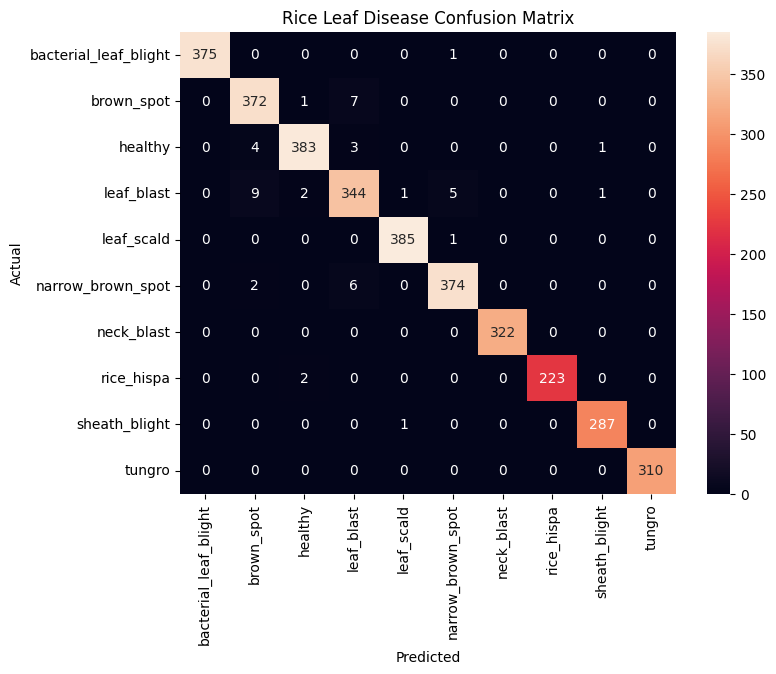

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

y_true = np.concatenate([y for _, y in test_ds], axis=0)
y_pred = np.argmax(model.predict(test_ds), axis=1)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=test_ds.class_names,
            yticklabels=test_ds.class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Rice Leaf Disease Confusion Matrix")
plt.show()


Ensuring dataset is available...
Using Colab cache for faster access to the 'rice-leaf-diseases-detection' dataset.
Training folder re-established: /kaggle/input/rice-leaf-diseases-detection/Rice_Leaf_Diease/Rice_Leaf_Diease/train

Found 10 classes:
Total images: 15023
Number of classes: 10
Test set size re-established: 2254
Test generator re-created.
Loading Stage 1 model from Drive...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Stage 1 model loaded successfully.

Generating predictions for Stage 1 model...
141/141 ━━━━━━━━━━━━━━━━━━━━ 63s 410ms/step
Calculating Confusion Matrix for Stage 1 model...


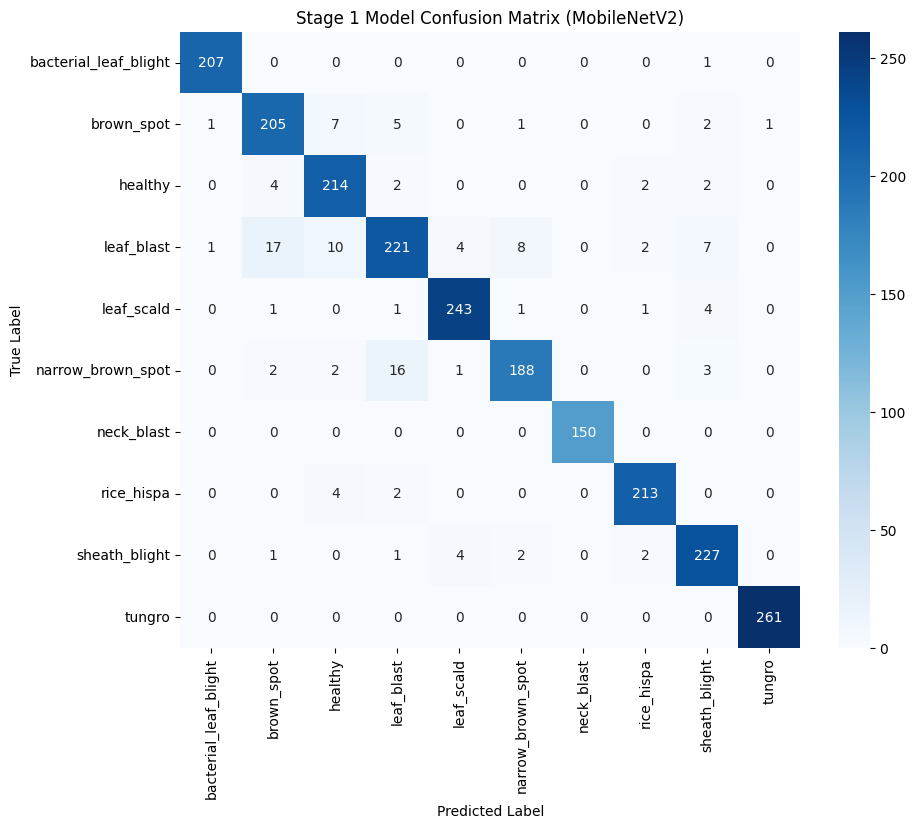


Classification Report for Stage 1 Model:
                       precision    recall  f1-score   support

bacterial_leaf_blight       0.99      1.00      0.99       208
           brown_spot       0.89      0.92      0.91       222
              healthy       0.90      0.96      0.93       224
           leaf_blast       0.89      0.82      0.85       270
           leaf_scald       0.96      0.97      0.97       251
    narrow_brown_spot       0.94      0.89      0.91       212
           neck_blast       1.00      1.00      1.00       150
           rice_hispa       0.97      0.97      0.97       219
        sheath_blight       0.92      0.96      0.94       237
               tungro       1.00      1.00      1.00       261

             accuracy                           0.94      2254
            macro avg       0.95      0.95      0.95      2254
         weighted avg       0.94      0.94      0.94      2254



In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, applications
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os
from glob import glob
import kagglehub

# ===== CONFIG (Re-define as these might be lost after runtime disconnection) =====
IMG_SIZE = (160, 160)
BATCH_SIZE = 16

# ===== Re-DOWNLOAD DATASET (if necessary, or ensure path is set) =====
# This call is idempotent if the dataset is already cached by kagglehub
print("Ensuring dataset is available...")
path = kagglehub.dataset_download("loki4514/rice-leaf-diseases-detection")
TRAIN_PATH = os.path.join(path, "Rice_Leaf_Diease/Rice_Leaf_Diease/train")
print("Training folder re-established:", TRAIN_PATH)

# ===== Re-GET FILE PATHS (DON'T LOAD IMAGES YET) =====
def get_file_paths(base_path):
    file_paths = []
    labels = []
    class_names = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])

    print(f"\nFound {len(class_names)} classes:")
    for idx, class_name in enumerate(class_names):
        # print(f"  {idx}: {class_name}") # Suppress verbose output
        class_path = os.path.join(base_path, class_name)
        img_files = glob(os.path.join(class_path, '*.[jJ][pP][gG]')) + \
                    glob(os.path.join(class_path, '*.[pP][nN][gG]'))

        # print(f"    Found {len(img_files)} images") # Suppress verbose output
        file_paths.extend(img_files)
        labels.extend([idx] * len(img_files))

    return file_paths, np.array(labels), class_names

file_paths, labels, CLASS_NAMES = get_file_paths(TRAIN_PATH)
NUM_CLASSES = len(CLASS_NAMES)

print(f"Total images: {len(file_paths)}")
print(f"Number of classes: {NUM_CLASSES}")

## ===== Re-SPLIT FILE PATHS (NOT IMAGES) =====
# Need to perform the split again to get `test_paths` and `y_test`
_, temp_paths, _, y_temp = train_test_split(
    file_paths, labels, test_size=0.3, stratify=labels, random_state=42
)
_, test_paths, _, y_test = train_test_split(
    temp_paths, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)
print(f"Test set size re-established: {len(test_paths)}")

# ===== Re-DEFINE MEMORY-EFFICIENT DATA GENERATOR =====
class MemoryEfficientGenerator(keras.utils.Sequence):
    def __init__(self, file_paths, labels, batch_size=16, img_size=(160, 160), augment=False, shuffle=True):
        self.file_paths = file_paths
        self.labels = labels
        self.batch_size = batch_size
        self.img_size = img_size
        self.augment = augment
        self.shuffle = shuffle
        self.indices = np.arange(len(file_paths))
        self.on_epoch_end()

    def __len__(self): # Changed to use \\ because this is JSON and \ is escape
        return int(np.ceil(len(self.file_paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]

        batch_images = []
        batch_labels = []

        for i in batch_indices:
            img = cv2.imread(self.file_paths[i])
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, self.img_size)
                img = img.astype('float32') / 255.0

                if self.augment and np.random.random() > 0.5:
                    if np.random.random() > 0.5:
                        img = np.fliplr(img)
                    if np.random.random() > 0.5:
                        img = np.flipud(img)

                batch_images.append(img)
                batch_labels.append(self.labels[i])

        return np.array(batch_images), keras.utils.to_categorical(batch_labels, NUM_CLASSES)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

# Re-create test generator
test_gen = MemoryEfficientGenerator(test_paths, y_test, BATCH_SIZE, IMG_SIZE, augment=False, shuffle=False)
print("Test generator re-created.")

# ===== LOAD STAGE 1 MODEL FROM DRIVE =====
print("Loading Stage 1 model from Drive...")
stage1_model = keras.models.load_model('/content/drive/MyDrive/models/rice_stage1_best.h5')
print("Stage 1 model loaded successfully.")

# ===== GENERATE HEATMAP FOR STAGE 1 MODEL =====
print("\nGenerating predictions for Stage 1 model...")
y_pred_s1_raw = stage1_model.predict(test_gen)
y_pred_s1 = np.argmax(y_pred_s1_raw, axis=1)

# Get true labels from the test generator
y_true_s1 = []
for _, labels in test_gen:
    y_true_s1.extend(np.argmax(labels, axis=1))
y_true_s1 = np.array(y_true_s1)

print("Calculating Confusion Matrix for Stage 1 model...")
cm_s1 = confusion_matrix(y_true_s1, y_pred_s1)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_s1, annot=True, fmt="d",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Stage 1 Model Confusion Matrix (MobileNetV2)")
plt.show()

print("\nClassification Report for Stage 1 Model:")
print(classification_report(y_true_s1, y_pred_s1, target_names=CLASS_NAMES))